数据加载完成:
  人脸数据集: 400 样本, 每个样本 4096 特征
  手写体数据集: 1797 样本, 每个样本 64 特征


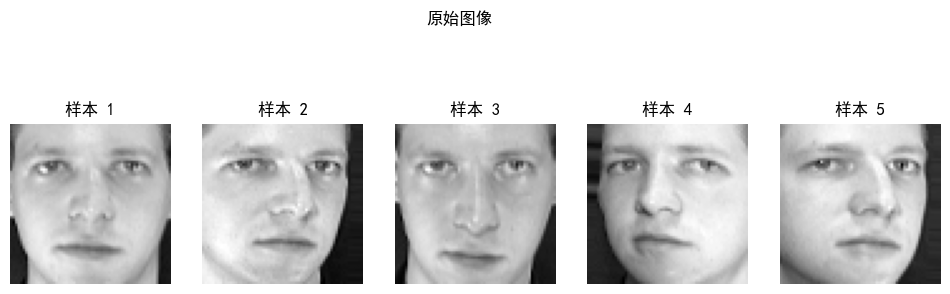

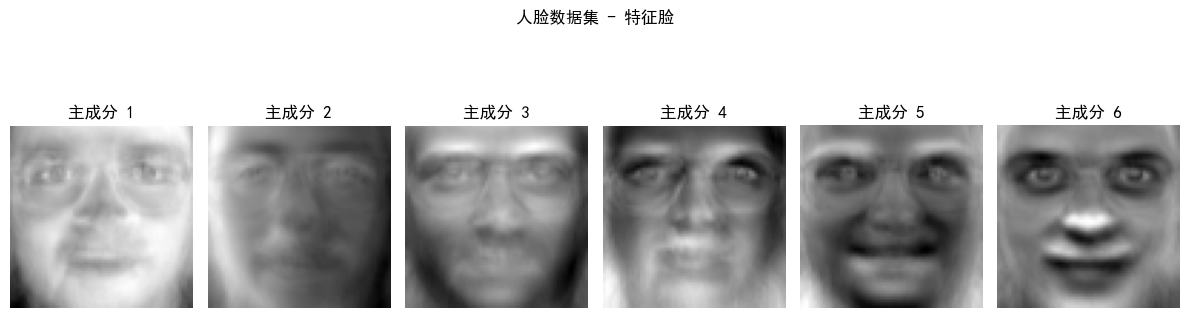

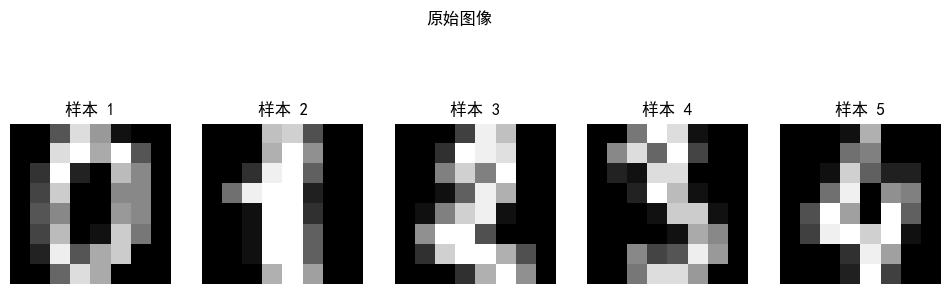

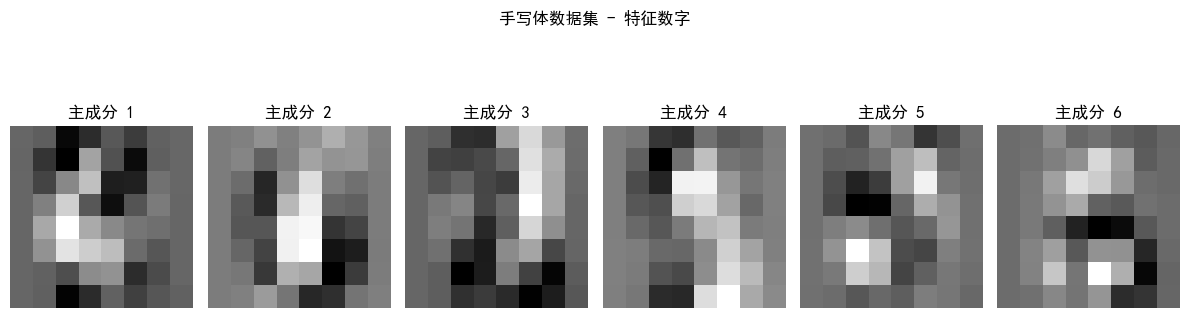

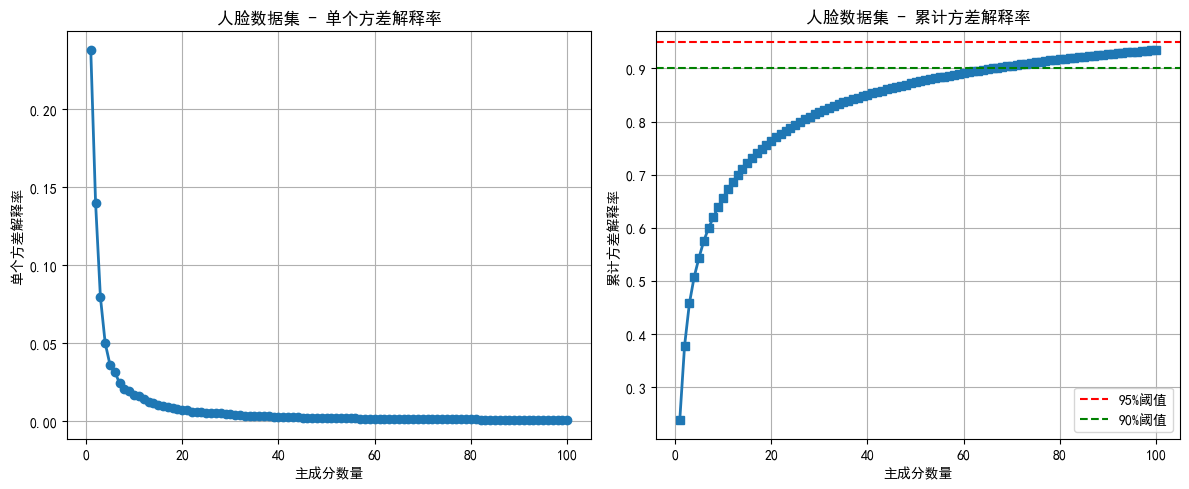

人脸数据集 - 方差解释率与主成分数量关系:
  保留 50.0% 方差需要 4 个主成分
  保留 70.0% 方差需要 14 个主成分
  保留 80.0% 方差需要 27 个主成分
  保留 90.0% 方差需要 66 个主成分
  保留 95.0% 方差需要 1 个主成分
  保留 99.0% 方差需要 1 个主成分


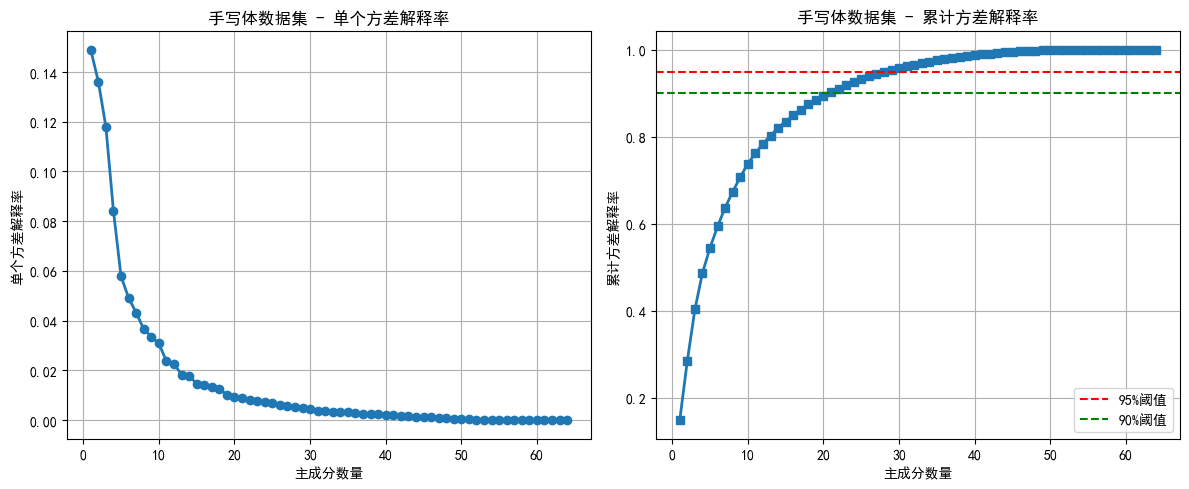

手写体数据集 - 方差解释率与主成分数量关系:
  保留 50.0% 方差需要 5 个主成分
  保留 70.0% 方差需要 9 个主成分
  保留 80.0% 方差需要 13 个主成分
  保留 90.0% 方差需要 21 个主成分
  保留 95.0% 方差需要 29 个主成分
  保留 99.0% 方差需要 41 个主成分


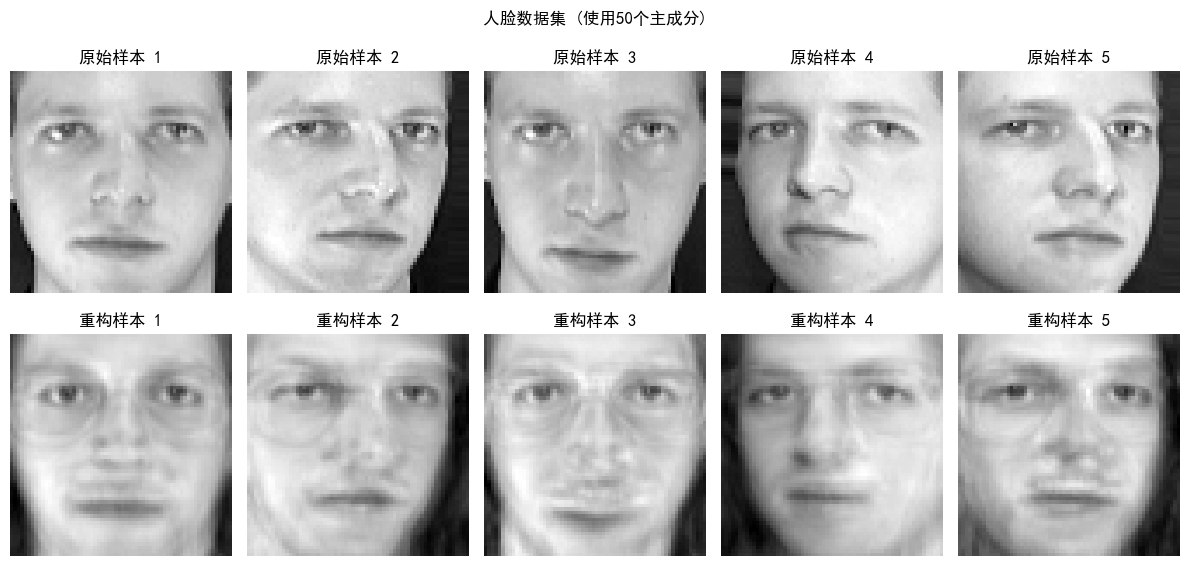

重构均方误差: 0.002438


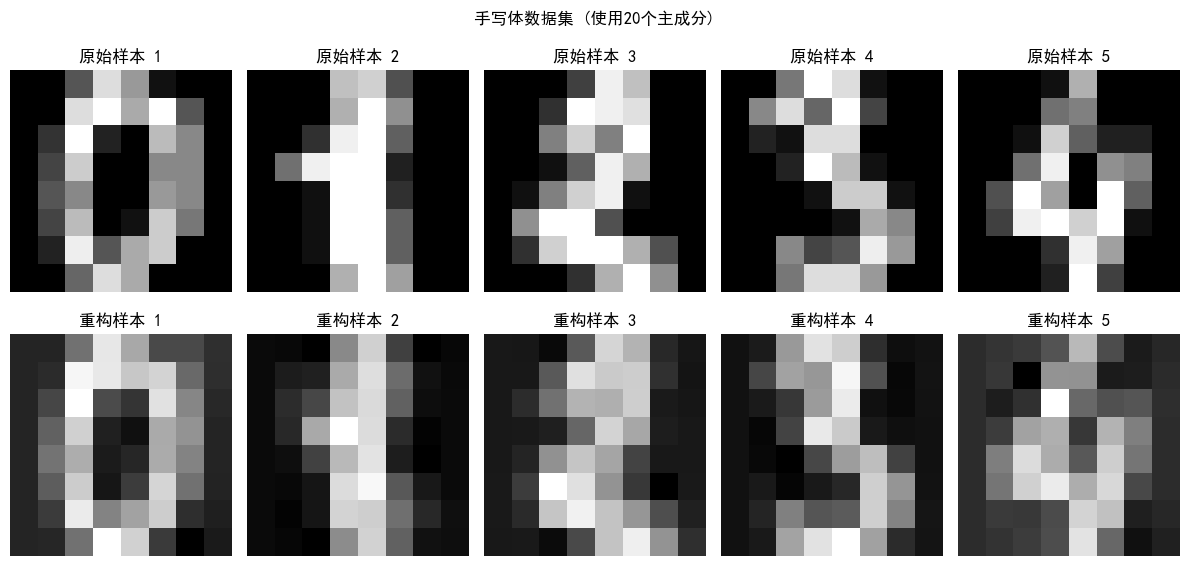

重构均方误差: 1.984259

人脸数据集 - 不同PCA维度下的分类性能:
  PCA(2维) + KNN: 准确率 = 0.2333
  PCA(5维) + KNN: 准确率 = 0.4917
  PCA(10维) + KNN: 准确率 = 0.6250
  PCA(20维) + KNN: 准确率 = 0.6917
  PCA(50维) + KNN: 准确率 = 0.7500
  PCA(100维) + KNN: 准确率 = 0.7750
  PCA(200维) + KNN: 准确率 = 0.7833


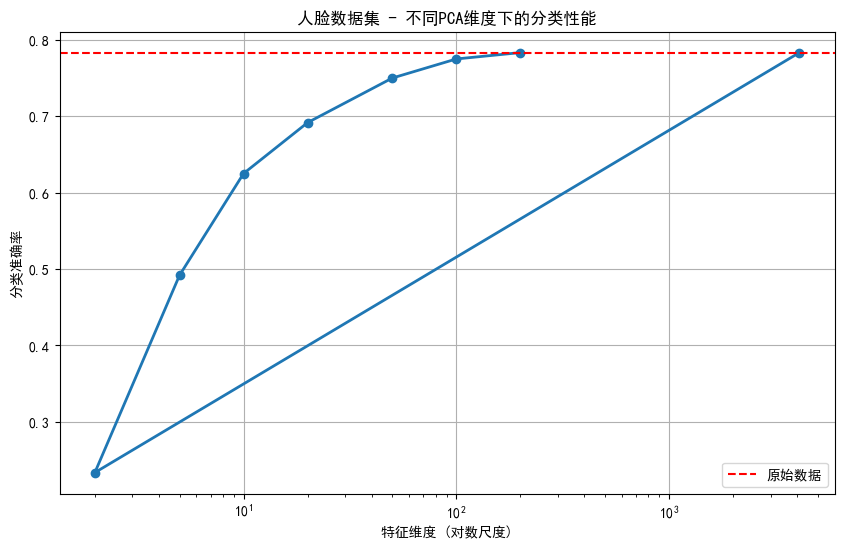


手写体数据集 - 不同PCA维度下的分类性能:
  PCA(2维) + KNN: 准确率 = 0.6315
  PCA(5维) + KNN: 准确率 = 0.9296
  PCA(10维) + KNN: 准确率 = 0.9778
  PCA(20维) + KNN: 准确率 = 0.9907
  PCA(50维) + KNN: 准确率 = 0.9926


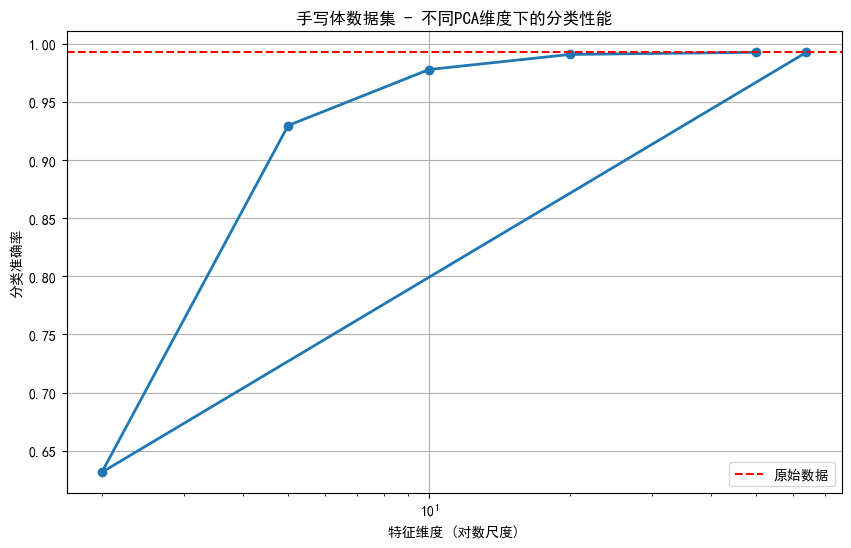


人脸数据集 - 网格搜索最优参数:
警告：检测到最小类别样本数为2，使用2折分层交叉验证
整体训练样本数: 280
交叉验证折内训练样本数: 140
特征维度: 4096
PCA最大组件数设置为: 139
实际使用的PCA组件数: [5, 10, 20, 50, 100, 139]
最优参数组合:
  PCA组件数: 139
  KNN邻居数: 3
  交叉验证准确率: 0.7107
  测试集准确率: 0.7917

手写体数据集 - 网格搜索最优参数:
整体训练样本数: 1257
交叉验证折内训练样本数: 1005
特征维度: 64
PCA最大组件数设置为: 63
实际使用的PCA组件数: [5, 10, 20, 50, 63]
最优参数组合:
  PCA组件数: 50
  KNN邻居数: 3
  交叉验证准确率: 0.9730
  测试集准确率: 0.9685


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces, load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler


# 设置中文显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 1. 加载数据集
def load_datasets():
    """加载人脸和手写体数据集"""
    # 加载人脸数据集
    faces = fetch_olivetti_faces()
    X_faces, y_faces = faces.data, faces.target
    face_images = faces.images  # 原始图像格式，用于可视化
    
    # 加载手写体数据集
    digits = load_digits()
    X_digits, y_digits = digits.data, digits.target
    digit_images = digits.images  # 原始图像格式，用于可视化
    
    print("数据加载完成:")
    print(f"  人脸数据集: {X_faces.shape[0]} 样本, 每个样本 {X_faces.shape[1]} 特征")
    print(f"  手写体数据集: {X_digits.shape[0]} 样本, 每个样本 {X_digits.shape[1]} 特征")
    
    return X_faces, y_faces, face_images, X_digits, y_digits, digit_images

# 2. 可视化原始数据和主成分
def visualize_principal_components(X, images, n_components=6, title="主成分可视化"):
    """可视化原始数据和前n个主成分"""
    # 计算PCA
    pca = PCA(n_components=n_components)
    pca.fit(X)
    
    # 可视化原始图像
    plt.figure(figsize=(12, 4))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"样本 {i+1}")
        plt.axis('off')
    plt.suptitle("原始图像")
    
    # 可视化主成分（特征脸/特征数字）
    plt.figure(figsize=(12, 4))
    for i in range(n_components):
        plt.subplot(1, n_components, i+1)
        if images.shape[1] == 8:  # 手写体
            plt.imshow(pca.components_[i].reshape(8, 8), cmap='gray')
        else:  # 人脸
            plt.imshow(pca.components_[i].reshape(64, 64), cmap='gray')
        plt.title(f"主成分 {i+1}")
        plt.axis('off')
    plt.suptitle(title)
    
    plt.tight_layout()
    plt.show()
    
    return pca

# 3. 分析方差解释率
def analyze_variance_explained(X, title, max_components=None):
    """分析不同维度下PCA的方差解释率"""
    if max_components is None:
        max_components = min(100, X.shape[1])
    
    # 计算不同维度下的方差解释率
    pca = PCA(n_components=max_components)
    pca.fit(X)
    
    # 绘制方差解释率曲线
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_components+1), pca.explained_variance_ratio_, 'o-', linewidth=2)
    plt.xlabel('主成分数量')
    plt.ylabel('单个方差解释率')
    plt.title(f"{title} - 单个方差解释率")
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, max_components+1), np.cumsum(pca.explained_variance_ratio_), 's-', linewidth=2)
    plt.axhline(y=0.95, color='r', linestyle='--', label='95%阈值')
    plt.axhline(y=0.90, color='g', linestyle='--', label='90%阈值')
    plt.xlabel('主成分数量')
    plt.ylabel('累计方差解释率')
    plt.title(f"{title} - 累计方差解释率")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 计算达到不同方差解释率所需的主成分数量
    thresholds = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
    print(f"{title} - 方差解释率与主成分数量关系:")
    for threshold in thresholds:
        n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= threshold) + 1
        print(f"  保留 {threshold*100:.1f}% 方差需要 {n_components} 个主成分")
    
    return pca

# 4. 可视化降维与重构效果
def visualize_reconstruction(X, images, n_components=20, title="PCA重构效果"):
    """可视化降维后的数据重构效果"""
    # 计算PCA并重构
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_reduced)
    
    # 可视化原始图像和重构图像
    plt.figure(figsize=(12, 6))
    n_samples = 5
    
    for i in range(n_samples):
        # 原始图像
        plt.subplot(2, n_samples, i+1)
        if images.shape[1] == 8:  # 手写体
            plt.imshow(images[i], cmap='gray')
        else:  # 人脸
            plt.imshow(images[i], cmap='gray')
        plt.title(f"原始样本 {i+1}")
        plt.axis('off')
        
        # 重构图像
        plt.subplot(2, n_samples, n_samples+i+1)
        if images.shape[1] == 8:  # 手写体
            plt.imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
        else:  # 人脸
            plt.imshow(X_reconstructed[i].reshape(64, 64), cmap='gray')
        plt.title(f"重构样本 {i+1}")
        plt.axis('off')
    
    plt.suptitle(f"{title} (使用{n_components}个主成分)")
    plt.tight_layout()
    plt.show()
    
    # 计算重构误差
    mse = np.mean((X - X_reconstructed) ** 2)
    print(f"重构均方误差: {mse:.6f}")
    
    return pca

# 5. 对比不同维度的分类性能
def compare_classification_performance(X, y, title, n_components_list=None):
    """对比不同PCA维度下的分类性能"""
    if n_components_list is None:
        n_components_list = [2, 5, 10, 20, 50, 100, 200]
    
    # 分割数据集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 原始数据上的分类性能
    knn_original = KNeighborsClassifier(n_neighbors=5)
    knn_original.fit(X_train, y_train)
    accuracy_original = knn_original.score(X_test, y_test)
    
    # 不同PCA维度下的分类性能
    accuracies = [accuracy_original]
    dims = [X_train.shape[1]]
    
    for n_components in n_components_list:
        if n_components >= X_train.shape[1]:
            continue
        
        # PCA + KNN
        pipeline = Pipeline([
            ('pca', PCA(n_components=n_components)),
            ('knn', KNeighborsClassifier(n_neighbors=5))
        ])
        
        pipeline.fit(X_train, y_train)
        accuracy = pipeline.score(X_test, y_test)
        
        accuracies.append(accuracy)
        dims.append(n_components)
        
        print(f"  PCA({n_components}维) + KNN: 准确率 = {accuracy:.4f}")
    
    # 绘制性能对比图
    plt.figure(figsize=(10, 6))
    plt.plot(dims, accuracies, 'o-', linewidth=2)
    plt.axhline(y=accuracy_original, color='r', linestyle='--', label='原始数据')
    plt.xscale('log')
    plt.xlabel('特征维度 (对数尺度)')
    plt.ylabel('分类准确率')
    plt.title(f"{title} - 不同PCA维度下的分类性能")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return accuracies, dims

# 6. 网格搜索最优参数
def grid_search_best_params(X, y):
    """使用网格搜索找到PCA+KNN的最优参数"""
    # 分割数据集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 创建Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('knn', KNeighborsClassifier())
    ])
    
    # 检查每个类别的样本数
    unique, counts = np.unique(y_train, return_counts=True)
    min_samples = min(counts)
    
    # 根据最小样本数选择合适的交叉验证策略
    if min_samples < 5:
        # 使用分层3折交叉验证
        cv_strategy = StratifiedKFold(n_splits=min(3, min_samples))
        print(f"警告：检测到最小类别样本数为{min_samples}，使用{cv_strategy.n_splits}折分层交叉验证")
    else:
        # 默认使用5折分层交叉验证
        cv_strategy = StratifiedKFold(n_splits=5)
    
    # 动态调整PCA的n_components参数范围，确保不超过交叉验证折内的最小样本数和特征维度
    fold_size = int(len(X_train) * (1 - 1/cv_strategy.n_splits))  # 每一折的训练样本数
    feature_dim = X_train.shape[1]  # 特征维度
    max_components = min(200, fold_size - 1, feature_dim - 1)  # 减1是为了保险起见
    print(f"整体训练样本数: {len(X_train)}")
    print(f"交叉验证折内训练样本数: {fold_size}")
    print(f"特征维度: {feature_dim}")
    print(f"PCA最大组件数设置为: {max_components}")
    
    # 生成动态参数网格，确保所有n_components值都不超过max_components
    pca_components = [5, 10, 20, 50]
    # 只添加不超过max_components的值
    if max_components >= 100:
        pca_components.append(100)
    if max_components > max(pca_components):
        pca_components.append(max_components)
    
    print(f"实际使用的PCA组件数: {pca_components}")
    
    # 定义参数网格
    param_grid = {
        'pca__n_components': pca_components,
        'knn__n_neighbors': [3, 5, 7, 9, 11]
    }
    
    # 执行网格搜索
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv_strategy, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    print("最优参数组合:")
    print(f"  PCA组件数: {grid_search.best_params_['pca__n_components']}")
    print(f"  KNN邻居数: {grid_search.best_params_['knn__n_neighbors']}")
    print(f"  交叉验证准确率: {grid_search.best_score_:.4f}")
    
    # 在测试集上评估
    best_model = grid_search.best_estimator_
    test_accuracy = best_model.score(X_test, y_test)
    print(f"  测试集准确率: {test_accuracy:.4f}")
    
    return best_model, test_accuracy

# 7. 主函数
def main():
    # 加载数据
    X_faces, y_faces, face_images, X_digits, y_digits, digit_images = load_datasets()
    
    # 可视化主成分（特征脸/特征数字）
    visualize_principal_components(X_faces, face_images, title="人脸数据集 - 特征脸")
    visualize_principal_components(X_digits, digit_images, title="手写体数据集 - 特征数字")
    
    # 分析方差解释率
    analyze_variance_explained(X_faces, "人脸数据集")
    analyze_variance_explained(X_digits, "手写体数据集")
    
    # 可视化重构效果
    visualize_reconstruction(X_faces, face_images, n_components=50, title="人脸数据集")
    visualize_reconstruction(X_digits, digit_images, n_components=20, title="手写体数据集")
    
    # 对比分类性能
    print("\n人脸数据集 - 不同PCA维度下的分类性能:")
    compare_classification_performance(X_faces, y_faces, "人脸数据集")
    
    print("\n手写体数据集 - 不同PCA维度下的分类性能:")
    compare_classification_performance(X_digits, y_digits, "手写体数据集")
    
    # 网格搜索最优参数
    print("\n人脸数据集 - 网格搜索最优参数:")
    grid_search_best_params(X_faces, y_faces)
    
    print("\n手写体数据集 - 网格搜索最优参数:")
    grid_search_best_params(X_digits, y_digits)

if __name__ == "__main__":
    main()
